# 08 – Vertiefung: Würfelspiel-Simulation und Histogramm

Wir simulieren ein **Würfelspiel**: Mit $k$ Würfeln werfen, die Augenzahlen addieren und diesen Vorgang $N$-mal wiederholen. Die **Summen** speichern wir in einer Liste und visualisieren sie mit einem **Histogramm**. Dabei zeigt sich ein wichtiges Phänomen der Statistik: die Annäherung an die **Normalverteilung** (Zentraler Grenzwertsatz).

**Navigation:** [← 08_Zufallszahlen (Hauptkapitel)](08_Zufallszahlen.ipynb) | Würfelspiel & Histogramm

## Aufgabenstellung

1. **$k$ Würfel** – pro Wurf erzeugen wir $k$ gleichverteilte Augenzahlen (1 bis 6).
2. **Summe** – die $k$ Augenzahlen werden addiert → ein **Gesamtergebnis** pro Wurf.
3. **$N$ Wiederholungen** – wir werfen $N$-mal und speichern die $N$ Summen in einer **Liste**.
4. **Histogramm** – wir plotten die Verteilung der gespeicherten Summen.

**Fragen:** Was erkennst du im Histogramm? Welche Verteilungsfunktion wird angenähert? Welches Theorem beschreibt, dass aus vielen Gleichverteilungen eine Normalverteilung entsteht?

## Simulation: Würfe erzeugen und Summen speichern

Mit **`np.random.randint(1, 7, size=(N, k))`** erzeugen wir $N \times k$ Zufallszahlen: jede Zeile entspricht einem Wurf mit $k$ Würfeln (Augenzahlen 1, 2, …, 6). Die **Summe pro Zeile** (Summe pro Wurf) erhalten wir mit **`.sum(axis=1)`**. Das Ergebnis ist ein Array der Länge $N$, das wir als Liste verwenden können.

In [1]:
import numpy as np

np.random.seed(42)

k = 4   # Anzahl Würfel pro Wurf
N = 10_000   # Anzahl Würfe (Versuche)

# N x k Matrix: jede Zeile = ein Wurf mit k Würfeln (Augen 1..6)
wuerfe = np.random.randint(1, 7, size=(N, k))

# Pro Zeile (pro Wurf) die Augensumme bilden
summen = wuerfe.sum(axis=1)

# Als Liste speichern (für die Aufgabenstellung)
augenzahlen_liste = summen.tolist()

print(f"Anzahl Würfel k = {k}, Anzahl Versuche N = {N}")
print(f"Kleinste Summe: {summen.min()}, Größte Summe: {summen.max()}")
print(f"Erste 10 Summen: {augenzahlen_liste[:10]}")

Anzahl Würfel k = 4, Anzahl Versuche N = 10000
Kleinste Summe: 4, Größte Summe: 24
Erste 10 Summen: [17, 13, 15, 17, 18, 12, 16, 9, 20, 17]


## Histogramm der Augensummen

Wir plotten die **Häufigkeit**, mit der jede Augensumme vorkommt. Die möglichen Summen liegen zwischen $k$ (alle Einsen) und $6k$ (alle Sechsen).

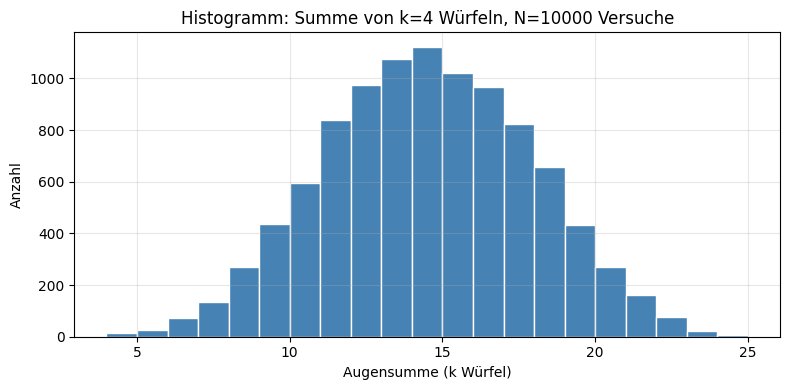

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(augenzahlen_liste, bins=range(k, 6*k+2), color="steelblue", edgecolor="white", density=False)
plt.xlabel("Augensumme (k Würfel)")
plt.ylabel("Anzahl")
plt.title(f"Histogramm: Summe von k={k} Würfeln, N={N} Versuche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Was sollten wir erkennen?

Das Histogramm ist **glockenförmig** (annähernd symmetrisch um die Mitte): Die mittleren Summen (z. B. bei $k=4$ Würfeln um 14) treten am häufigsten auf, nach außen hin werden die Werte seltener. Das ist **kein** Rechteck wie bei einer einzelnen Gleichverteilung (ein Würfel 1–6), sondern eine **Glockenkurve**.

**Welche Verteilungsfunktion wird angenähert?**  
→ Die **Normalverteilung** (Gauß-Verteilung). Die Summe von $k$ unabhängigen gleichverteilten Zufallsgrößen (hier: Augenzahlen 1–6) ist für größeres $k$ näherungsweise **normalverteilt**.

## Welches Theorem?

Das beschreibt der **Zentrale Grenzwertsatz** (engl. *Central Limit Theorem*, CLT):

**Zentraler Grenzwertsatz (vereinfacht):**  
Summiert man **viele** unabhängige Zufallsgrößen mit gleicher (oder ähnlicher) Verteilung, so ist die **Verteilung der Summe** unter milden Bedingungen **annähernd normalverteilt** – unabhängig davon, wie die Einzelverteilung aussieht (ob Gleichverteilung wie beim Würfel oder etwas anderes).

Bei **einem** Würfel: Gleichverteilung (jede Augenzahl 1–6 gleich wahrscheinlich).  
Bei **vielen** Würfeln: Die **Summe** der Augenzahlen wird mit wachsendem $k$ immer besser durch eine **Normalverteilung** beschrieben. Das ist einer der Gründe, warum die Normalverteilung in der Statistik und in der Kommunikationstechnik (z. B. Rauschen) so zentral ist.

## Optional: Einfluss von $k$

Du kannst $k$ und $N$ im Code oben ändern:
- **$k = 1$:** Histogramm ist (diskret) gleichverteilt über 1, 2, …, 6 – keine Glocke.
- **$k = 2, 3, 4, \ldots$:** Die Glockenform wird mit größerem $k$ deutlicher.
- **$N$ groß** (z. B. 10 000 oder 50 000): Die empirische Verteilung passt besser zur theoretischen Glockenkurve.